In [ ]:
import tensorflow as tf
from tensorflow import keras
import pathlib
import glob
import PIL
import numpy as np
import os
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten
from keras.optimizers import AdamW
from keras.losses import SparseCategoricalCrossentropy

In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file(origin=dataset_url, extract=True)
data_dir = pathlib.Path(archive).with_suffix('')


In [3]:
data_dir = "/mnt/c/Users/Mousavi/Downloads/5_flowers"
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('/mnt/c/Users/Mousavi/Downloads/5_flowers')

In [4]:
num_images = len(list(data_dir.glob("*/*.jpg")))
print(f"Number of images from all 5 kind of flowers: {num_images}")

Number of images from all 5 kind of flowers: 5019


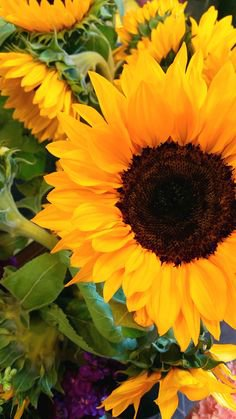

In [5]:
Sunflowers_path = list(data_dir.glob("Sunflower/*.jpg"))
Sunflowers_path = [str(path) for path in Sunflowers_path]

PIL.Image.open(Sunflowers_path[0])

In [6]:
data_path = tf.data.Dataset.list_files(file_pattern="/mnt/c/Users/Mousavi/Downloads/5_flowers/*/*.jpg", seed=42, shuffle=False)
next(iter(data_path))

W0000 00:00:1777090083.643114  325437 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


<tf.Tensor: shape=(), dtype=string, numpy=b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Lilly/00048a5c76.jpg'>

In [7]:
data_path = data_path.shuffle(buffer_size=len(data_path), reshuffle_each_iteration=False)   # Shuffle in every epoch is False.

In [8]:
for data in data_path.take(5):
    print(data.numpy())

b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Orchid/facb23798d.jpg'
b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Orchid/2cb0c8dd9b.jpg'
b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Lilly/d43e3f26c8(1).jpg'
b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Lilly/adc1a9b5df.jpg'
b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Sunflower/a7be309a2a.jpg'


In [9]:
classes = []

for i in data_dir.glob("*"):
    classes.append(str(i).split("/")[-1])    

classes = np.array(classes)
classes

array(['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip'], dtype='<U9')

In [10]:
val_size = int(0.2 * num_images)

val_data_path = data_path.take(val_size)
train_data_path = data_path.skip(val_size)


print(f"Number of all data path is: {len(data_path)}")
print(f"Number of train data path is: {len(train_data_path)}")
print(f"Number of val data path is: {len(val_data_path)}")

Number of all data path is: 5019
Number of train data path is: 4016
Number of val data path is: 1003


In [11]:
def get_label(path):
    # path = str(path)
    # class_name = str(path).split("/")[-2]
    class_name = tf.strings.split(path, os.path.sep)
    one_hot = class_name[-2] == classes
    
    return tf.argmax(one_hot)

In [12]:
get_label(b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Lilly/ec20455368.jpg')

<tf.Tensor: shape=(), dtype=int64, numpy=0>

In [13]:
for i in data_path.take(5):
    print(get_label(i))

tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(2, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(0, shape=(), dtype=int64)
tf.Tensor(3, shape=(), dtype=int64)


In [14]:
def decode_iamge(image_path, image_height=512, image_width=512):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    
    return tf.image.resize(image, [image_height, image_width])

In [15]:
def process_path(path):
    label = get_label(path)
    image = decode_iamge(path, 512, 512)

    return image, label

In [16]:
image, label = process_path(b'/mnt/c/Users/Mousavi/Downloads/5_flowers/Lotus/284605b5cd.jpg')

In [17]:
label

<tf.Tensor: shape=(), dtype=int64, numpy=1>

In [18]:
image

<tf.Tensor: shape=(512, 512, 3), dtype=float32, numpy=
array([[[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       ...,

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [254., 254., 254.]],

       [[254., 25

In [19]:
train_data = train_data_path.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
val_data = val_data_path.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

In [20]:
for image, label in train_data.take(5):
    print(f"Shape of image: {image.shape}")
    print(f"Shape of label: {label.shape}")

Shape of image: (512, 512, 3)
Shape of label: ()
Shape of image: (512, 512, 3)
Shape of label: ()
Shape of image: (512, 512, 3)
Shape of label: ()
Shape of image: (512, 512, 3)
Shape of label: ()
Shape of image: (512, 512, 3)
Shape of label: ()


In [21]:
def configure_for_performance(ds, batch_size):
    ds = ds.cache()
    ds = ds.shuffle(buffer_size=1000)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

In [22]:
batch_size = 32

train_data = configure_for_performance(train_data, batch_size)
val_data = configure_for_performance(val_data, batch_size)

In [23]:
for images, labels in train_data.take(1):
    print(images.shape)
    print(labels.shape)

(32, 512, 512, 3)
(32,)


W0000 00:00:1777090089.289910  325721 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [24]:
images, labels = next(iter(train_data))

W0000 00:00:1777090091.579300  325437 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


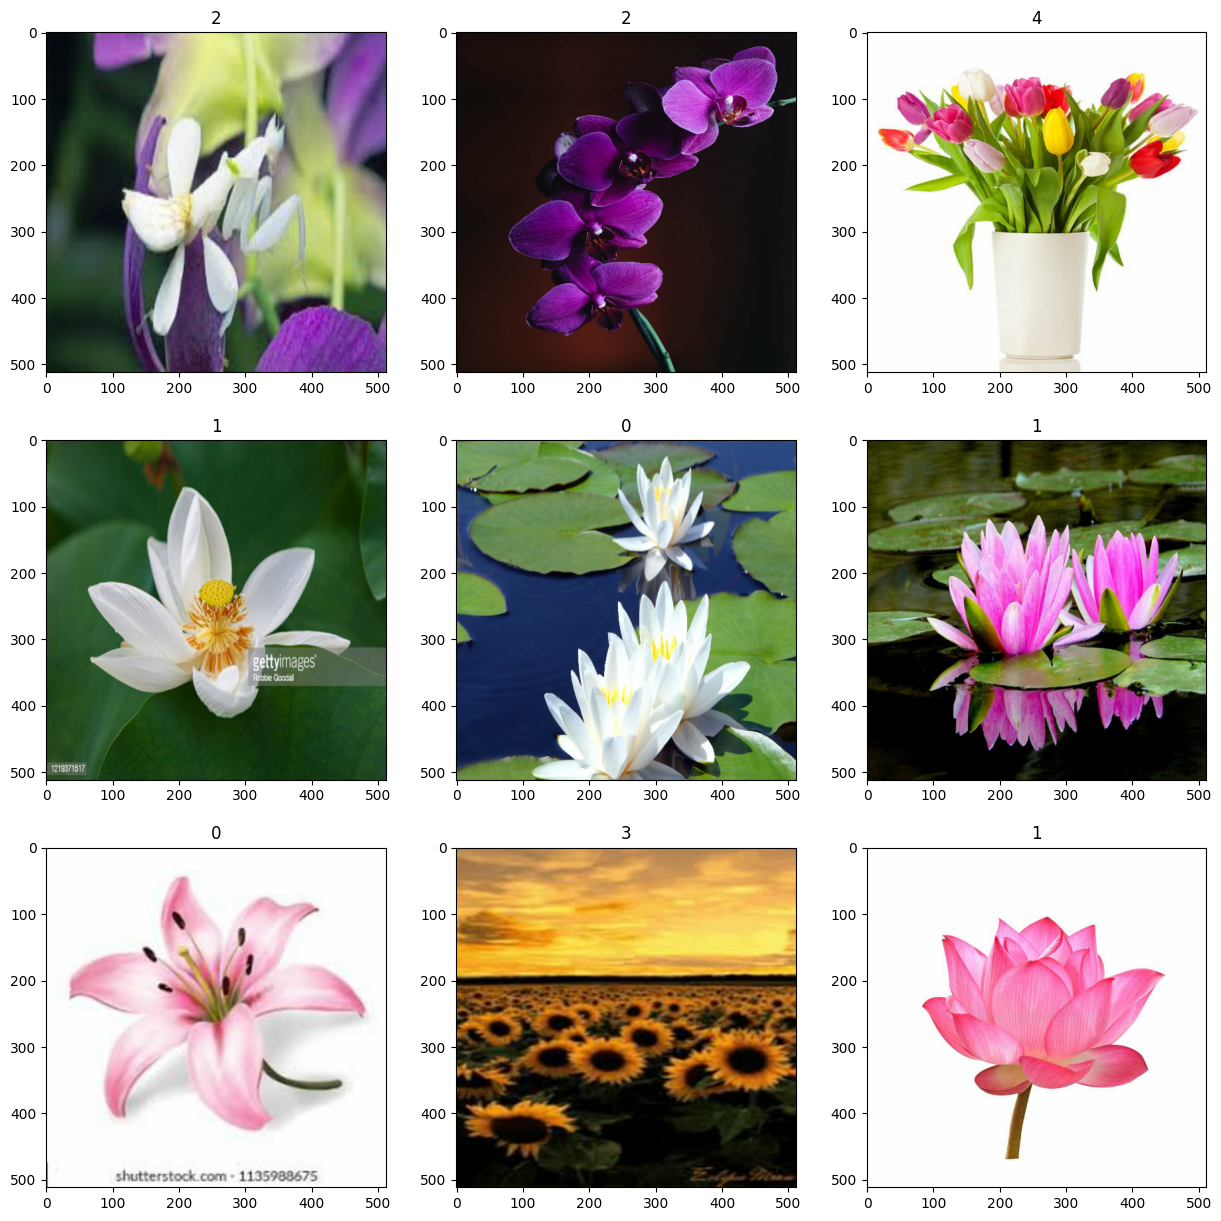

In [25]:
plt.figure(figsize=(15, 15))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype(np.uint(8)))
    plt.title(labels[i].numpy())

## Create the Model

In [26]:
model = Sequential()
model.add(keras.layers.Input((512, 512, 3)))
model.add(keras.layers.Rescaling(1./255))

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPool2D())

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(Dense(5))


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,547,141 (120.34 MB)

 Trainable params: 31,547,141 (120.34 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer=AdamW(learning_rate=1e-3),
              loss=SparseCategoricalCrossentropy(from_logits=True), 
              metrics=['accuracy']
              )

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.21.0
GPU devices: []


: 

In [ ]:
history = model.fit(train_data,
                    epochs=2,
                    validation_data=val_data)

Epoch 1/2


W0000 00:00:1777090096.523050  325778 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 100663552 bytes after encountering the first element of size 100663552 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
